# Day 9
## Part 1: Largest rectangle

We are given a set of coordinates

In [9]:
with open("09.txt") as f:
    coords: list[tuple[int, int]]
    coords = [tuple(map(int, line.split(','))) for line in f.readlines()]  # type: ignore

def pairs[T](iter: list[T]):
    for i, a in enumerate(iter):
        for b in iter[i+1:]:
            yield a, b

def area(
    a: tuple[int, int],
    b: tuple[int, int]):
    ax, ay = a
    bx, by = b
    return abs((ax-bx + 1) * (ay-by + 1))

largest = sorted(
    ((area(*pair), pair) for pair in pairs(coords)), reverse=True
)
largest[0]

(4758598740, ((83899, 85263), (16133, 15044)))

## Part 2: Inside a loop
The coordinates specify a shape, each coordinate alternating between row and column, and the largest rectangle should be wholly inside the shape. How scary! Let's take a look at the shape:

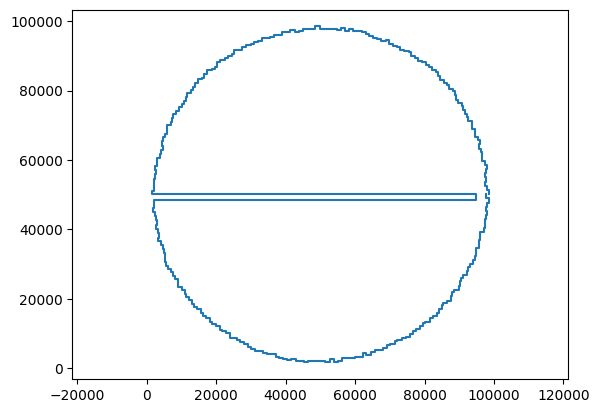

In [10]:
from matplotlib import pyplot
import numpy

x, y = numpy.array(coords).T
pyplot.plot(x, y, '-')
pyplot.axis('equal')
pyplot.show()

Our intuition is that any solution _must_ have a height less than ~25,000.

First let us define a line segment intersection function:

In [11]:
Point = tuple[int, int]

def cross(a: Point, b: Point):
    return (a[0] * b[1]) - (a[1] * b[0])

def orient(a: Point, b: Point, c: Point):
    # (b-a) × (c-a)
    ba = (b[0]-a[0], b[1]-a[1])
    ca = (c[0]-a[0], c[1]-a[1])
    return cross(ba, ca)

def intersects(a: tuple[Point, Point], b: tuple[Point, Point]):
    if len(set(a) & set(b)):
        # At least one point overlaps, so we can ignore it
        return False
    return (
        (orient(*b, a[0]) * orient(*b, a[1]) < 0) and
        (orient(*a, b[0]) * orient(*a, b[1]) < 0)
    )

1474666385


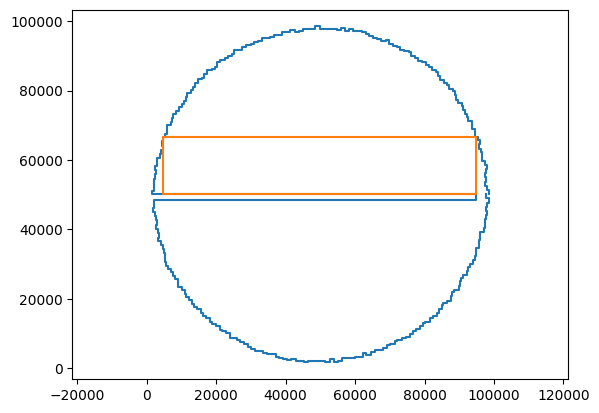

In [13]:
def rect_overlaps(bx0: int, bx1: int, by0: int, by1: int):
    A, B, C, D = (bx0, by0), (bx1, by0), (bx1, by1), (bx0, by1)
    rect_lines = (A, B), (B, C), (C, D), (D, A)
    return any(
        intersects(r, (coords[i], coords[(i+1) % len(coords)]))
        for i in range(len(coords))
        for r in rect_lines
    )

for area, ((bx0, by0), (bx1, by1)) in largest:
    A, B, C, D = (bx0, by0), (bx1, by0), (bx1, by1), (bx0, by1)
    bx0, bx1 = sorted((bx0, bx1))
    by0, by1 = sorted((by0, by1))

    if all(
        not rect_overlaps(bx0+i, bx1-i, by0+i, by1-i)
        for i in range(3)
    ):  
        print(area)
        break

# pyplot.plot()

pyplot.axis('equal')

x, y = numpy.array(coords).T
pyplot.plot(x, y, '-')

bx, by = numpy.array([A, B, C, D, A]).T
pyplot.plot(bx, by, '-')
pyplot.show()
# 1474666385 is too low
# 4681016340 is too high

I still haven't figured this one out :(